<a href="https://colab.research.google.com/github/Iditc/log-anomaly-detection/blob/main/notebooks/09_llm_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Install Anthropic SDK
!pip install anthropic -q

In [9]:
# Imports and paths
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path('/content/drive/MyDrive/log-anomaly-detection')
DATA_PROC = BASE / 'data' / 'processed'
RESULTS = BASE / 'results'

In [10]:
# Set API key — enter your key when prompted
from google.colab import userdata
import anthropic

# Option 1: paste directly (less secure)
API_KEY = "YOUR_KEY_HERE"

# Option 2: use Colab secrets (more secure)
# API_KEY = userdata.get('ANTHROPIC_API_KEY')

client = anthropic.Anthropic(api_key=API_KEY)
print("Client ready.")

Client ready.


In [13]:
# Reload data and sample
df = pd.read_parquet(DATA_PROC / "hdfs_full_parsed.parquet")

blocks = df.groupby("block_id").agg(
    log_lines=("log_line", list),
    label=("Label", "first")
).reset_index()

normal_sample = blocks[blocks["label"] == "Normal"].sample(100, random_state=42)
anomaly_sample = blocks[blocks["label"] == "Anomaly"].sample(100, random_state=42)
sample = pd.concat([normal_sample, anomaly_sample]).reset_index(drop=True)

normal_test = sample[sample["label"] == "Normal"].iloc[0]
anomaly_test = sample[sample["label"] == "Anomaly"].iloc[0]

print(f"Sample ready: {len(sample)} blocks")

Sample ready: 200 blocks


In [20]:
# Improved prompt with HDFS context and few-shot examples
def classify_block_v2(client, log_lines):
    """Enhanced prompt with domain knowledge and examples."""
    logs_text = "\n".join(log_lines[:30])

    message = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=100,
        messages=[{
            "role": "user",
            "content": f"""You are an HDFS (Hadoop Distributed File System) log analyst.
A block goes through a lifecycle: allocate → receive → respond → complete.
An anomaly block may have: missing steps, WARN messages, unexpected errors, replication requests, or very few log lines.

Example Normal block:
- Receiving block, PacketResponder terminating, blockMap updated (complete lifecycle)

Example Anomaly block:
- Receiving block, WARN Unexpected error trying to delete block (error + incomplete lifecycle)

Now analyze these log lines from a single block:
{logs_text}

Answer with ONLY one word: Normal or Anomaly"""
        }]
    )
    return message.content[0].text.strip()

# Test on same two blocks
print("Normal block →", classify_block_v2(client, normal_test["log_lines"]))
print("Anomaly block →", classify_block_v2(client, anomaly_test["log_lines"]))

Normal block → Normal
Anomaly block → Anomaly


In [21]:
# Classify all 200 sample blocks with improved prompt
import time

print("Classifying 200 blocks with improved prompt...")
y_true = []
y_pred = []

for i, row in sample.iterrows():
    true_label = row["label"]
    pred_label = classify_block_v2(client, row["log_lines"])

    y_true.append(true_label)
    y_pred.append(pred_label)

    if (len(y_true)) % 20 == 0:
        print(f"  Processed {len(y_true)} / 200...")

print("Done!")

Classifying 200 blocks with improved prompt...
  Processed 20 / 200...
  Processed 40 / 200...
  Processed 60 / 200...
  Processed 80 / 200...
  Processed 100 / 200...
  Processed 120 / 200...
  Processed 140 / 200...
  Processed 160 / 200...
  Processed 180 / 200...
  Processed 200 / 200...
Done!


In [ ]:
!pip install --upgrade anthropic -q

              precision    recall  f1-score   support

      Normal       0.82      0.70      0.76       100
     Anomaly       0.74      0.85      0.79       100

    accuracy                           0.78       200
   macro avg       0.78      0.77      0.77       200
weighted avg       0.78      0.78      0.77       200



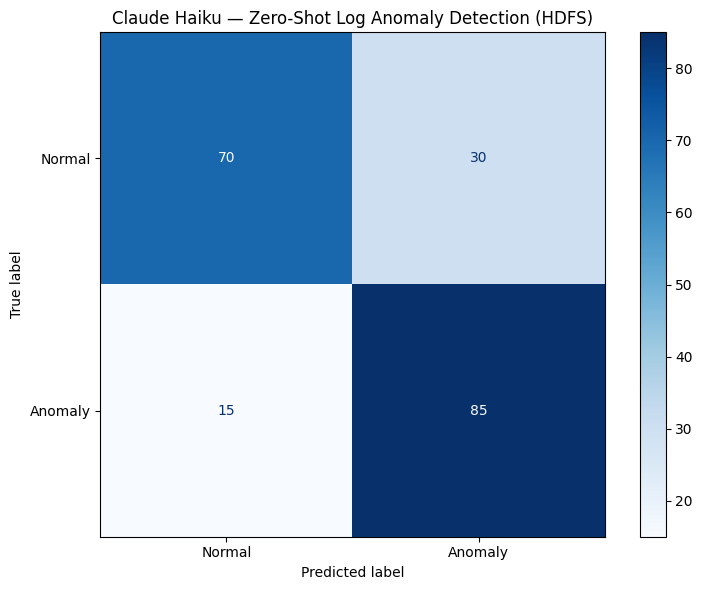

In [22]:
# Evaluate LLM results
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert predictions to match label format
y_true_binary = [1 if l == "Anomaly" else 0 for l in y_true]
y_pred_binary = [1 if l == "Anomaly" else 0 for l in y_pred]

print(classification_report(y_true_binary, y_pred_binary, target_names=["Normal", "Anomaly"]))

# Confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomaly"])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format=",")
ax.set_title("Claude Haiku — Zero-Shot Log Anomaly Detection (HDFS)")
plt.tight_layout()
plt.savefig(str(RESULTS / "llm_confusion_matrix.png"), dpi=150)
plt.show()


In [16]:
# Find working Sonnet model
models_to_try = [
    "claude-sonnet-4-20250514",
    "claude-3-7-sonnet-20250219",
    "claude-3-5-sonnet-20241022",
    "claude-haiku-4-5-20251001",
]

for m in models_to_try:
    try:
        msg = client.messages.create(
            model=m,
            max_tokens=10,
            messages=[{"role": "user", "content": "Say hi"}]
        )
        print(f"✓ {m} works")
    except Exception as e:
        print(f"✗ {m}: {type(e).__name__}")

/tmp/ipykernel_2026/1869315892.py:11: DeprecationWarning: The model 'claude-sonnet-4-20250514' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  msg = client.messages.create(
/tmp/ipykernel_2026/1869315892.py:11: DeprecationWarning: The model 'claude-3-7-sonnet-20250219' is deprecated and will reach end-of-life on February 19th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  msg = client.messages.create(


✗ claude-sonnet-4-20250514: NotFoundError
✗ claude-3-7-sonnet-20250219: NotFoundError
✗ claude-3-5-sonnet-20241022: NotFoundError
✓ claude-haiku-4-5-20251001 works
